In [1]:
%load_ext autoreload
%autoreload 2

In [14]:
import boto3
import icechunk
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd

from srm import catalog

In [3]:
def open_icechunk(path):
    bucket, prefix = path.replace("s3://", "").split("/", 1)
    storage = icechunk.s3_storage(bucket=bucket, prefix=prefix)
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")

    ds = xr.open_dataset(session.store, engine="zarr", chunks={})
    return ds

In [4]:
def resolve_s3_glob(path):
    """Resolve a single * wildcard in an S3 path to a real path."""
    bucket, prefix = path.replace("s3://", "").split("/", 1)

    before, after = prefix.split("*/", 1)

    s3 = boto3.client("s3")
    response = s3.list_objects_v2(Bucket=bucket, Prefix=before, Delimiter="/")

    matches = [f"s3://{bucket}/{cp['Prefix']}{after}" for cp in response.get("CommonPrefixes", [])]

    if not matches:
        raise ValueError(f"No S3 paths matched: {path}")
    if len(matches) > 1:
        raise ValueError(f"Multiple matches: {matches}")

    return matches[0]

In [43]:
ds_dict = {
'historical' : 
    catalog.get("CESM2-WACCM-historical-icechunk")
    .to_xarray()
    .sel(ensemble_member="001").sel(time=slice("1978", "2014")),
'ssp2-4.5' : 
    catalog.get("CESM2-WACCM-SSP245-icechunk")
    .to_xarray()
    .sel(ensemble_member="007").sel(time=slice("2015", "2070")),
'g6-1.5k' : 
    catalog.get("CESM2-WACCM-G6-1.5K-icechunk")
    .to_xarray()
    .sel(ensemble_member="001").sel(time=slice("2035", "2085"))}

In [48]:
dfs = []
for scenario, ds in ds_dict.items():
    _df = (
        ds.tas.mean(dim=['lat', 'lon'])
        .groupby('time.year')
        .mean()
        .to_dataframe()
        .reset_index()
    )
    _df['scenario'] = scenario
    _df['gcm'] = str(ds.model)
    _df['variable'] = 'tas_global'
    _df = _df.rename(columns={'tas': 'value'})
    dfs.append(_df)

df = pd.concat(dfs, ignore_index=True)[['year', 'scenario', 'ensemble_member', 'gcm', 'variable', 'value']]

<Axes: >

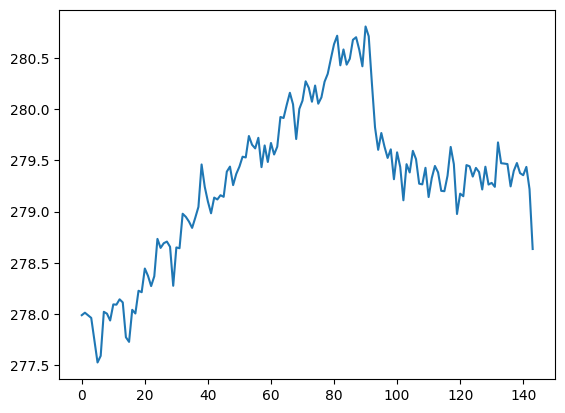

In [49]:
df.value.plot()

In [50]:
df

,year,scenario,ensemble_member,gcm,variable,value
0,1978,historical,001,CESM2-WACCM,tas_global,277.989471
1,1979,historical,001,CESM2-WACCM,tas_global,278.013763
2,1980,historical,001,CESM2-WACCM,tas_global,277.987976
3,1981,historical,001,CESM2-WACCM,tas_global,277.963074
4,1982,historical,001,CESM2-WACCM,tas_global,277.747803
...,...,...,...,...,...,...
139,2081,g6-1.5k,001,CESM2-WACCM,tas_global,279.375854
140,2082,g6-1.5k,001,CESM2-WACCM,tas_global,279.355682
141,2083,g6-1.5k,001,CESM2-WACCM,tas_global,279.436676
142,2084,g6-1.5k,001,CESM2-WACCM,tas_global,279.219604


In [51]:
df.to_csv('s3://carbonplan-srm/output/explainer/figures/figure2.csv')